<a href="https://colab.research.google.com/github/kacp-i/BCU-Work/blob/main/Y4%20S1%20CMP6232%20Deep%20Neural%20Networks%20and%20Ethics/CMP6232_Deep_Neural_Networks_and_Ethics_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building the model

## Step 1: Import the required libraries

First, import the modules needed to build the model:

In [1]:
from __future__ import print_function
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
np.random.seed(1671)  # for reproducibility

## Step 2: Define the training parameters

Set up the parameters that control training:

In [20]:
NB_EPOCH = 20            # number of training epochs
BATCH_SIZE = 128         # batch size for training
VERBOSE = 1              # verbosity mode
NB_CLASSES = 10          # number of classes (one per digit, 0-9)
OPTIMIZER = SGD()        # SGD optimiser
OPTIMIZER2 = SGD()
VALIDATION_SPLIT = 0.2   # fraction of TRAIN reserved for validation

## Step 3: Load and preprocess the data

Load the data, then reshape each 28 × 28 image into a flat vector of 784 values and normalise the pixels to [0,
1].

In [3]:
# data: shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

RESHAPED = 784
X_train = X_train.reshape(60000, RESHAPED)
X_test = X_test.reshape(10000, RESHAPED)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# normalise pixel values to the [0, 1] range
X_train /= 255
X_test /= 255

print(X_train.shape[0], 'train samples')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
60000 train samples


**Why normalise**  Each pixel intensity (0–255) is divided by 255, so all inputs sit between 0 and 1. <br>
Networks train faster and more reliably when inputs are on the same small scale.

## Step 4: Convert the labels to one-hot encoding

Convert the class labels into binary class matrices (one-hot vectors):

In [4]:
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test = to_categorical(y_test, NB_CLASSES)

## Step 5: Build the neural network model

Build a first, simple model: a single dense layer with a softmax output.

In [5]:
model = Sequential()
model.add(Dense(NB_CLASSES, input_shape=(RESHAPED,)))
model.add(Activation('softmax'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

**Understanding the model:**<br>
* The input has 784 values, one per pixel.
* The output layer has 10 neurons, one per digit.
* Softmax turns the outputs into class probabilities.

## Step 6: Compile the model

Before training, specify the loss function, the optimiser and the metrics to track:

In [6]:
model.compile(loss='categorical_crossentropy', optimizer=OPTIMIZER,
              metrics=['accuracy'])

* **Loss function** – measures the error (categorical cross-entropy for multi-class).
* **Optimiser** – decides how the weights are updated during training.
* **Metrics** – accuracy is used to track performance.

## Step 7: Train the model

Use fit() to train the model. The main hyperparameters are the number of epochs and the batch size:

In [7]:
history = model.fit(X_train, Y_train, batch_size=BATCH_SIZE,
                    epochs=NB_EPOCH, verbose=VERBOSE,
                    validation_split=VALIDATION_SPLIT)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6757 - loss: 1.3714 - val_accuracy: 0.8278 - val_loss: 0.8911
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8310 - loss: 0.7894 - val_accuracy: 0.8594 - val_loss: 0.6560
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8514 - loss: 0.6413 - val_accuracy: 0.8703 - val_loss: 0.5614
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8626 - loss: 0.5696 - val_accuracy: 0.8782 - val_loss: 0.5088
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.5259 - val_accuracy: 0.8827 - val_loss: 0.4748
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8734 - loss: 0.4960 - val_accuracy: 0.8863 - val_loss: 0.4507
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8774 - loss: 0.4737 - val_accuracy: 0.8912 - val_loss: 0.4326
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8808 - loss: 0.4564 - val_accuracy: 0.

* **epochs** – how many times the model sees the whole training set.
* **batch_size** – how many samples are seen before each weight update.

## Step 8: Evaluate the model

Evaluate the trained model on the test set. The test set should contain only unseen examples:

In [8]:
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("Test score:", score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9053 - loss: 0.3475
Test score: 0.34754711389541626
Test accuracy: 0.9053000211715698


**How accurate is your model?**  Note the accuracy. What percentage of the handwritten digits are
classified correctly? Keep this number to compare against your improved models.

# Improving the model

## First attempt: adding hidden layer(s)

In [12]:
# data: shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

RESHAPED = 784
X_train = X_train.reshape(60000, RESHAPED)
X_test = X_test.reshape(10000, RESHAPED)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# normalise pixel values to the [0, 1] range
X_train /= 255
X_test /= 255

print(X_train.shape[0], 'train samples')

60000 train samples


In [13]:
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test = to_categorical(y_test, NB_CLASSES)

You can improve the model by adding layers. After the input, add a dense hidden layer with N_HIDDEN
neurons, then a second hidden layer, then the output layer of 10 neurons. A layer is called hidden because it
connects to neither the input nor the output directly.

In [16]:
N_HIDDEN = 128
model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
model.add(Dense(N_HIDDEN))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

This is now a deep neural network. You can keep adding hidden layers to make it deeper. Recompile and
retrain it (Steps 6 and 7) to see how the accuracy changes.

In [21]:
model.compile(loss='categorical_crossentropy', optimizer=OPTIMIZER2,
              metrics=['accuracy'])

In [22]:
history = model.fit(X_train, Y_train, batch_size=BATCH_SIZE,
                    epochs=NB_EPOCH, verbose=VERBOSE,
                    validation_split=VALIDATION_SPLIT)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7599 - loss: 0.9238 - val_accuracy: 0.8682 - val_loss: 0.5118
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8692 - loss: 0.4757 - val_accuracy: 0.8890 - val_loss: 0.3981
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8860 - loss: 0.4040 - val_accuracy: 0.8994 - val_loss: 0.3584
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8946 - loss: 0.3718 - val_accuracy: 0.9043 - val_loss: 0.3369
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8996 - loss: 0.3525 - val_accuracy: 0.9096 - val_loss: 0.3241
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9031 - loss: 0.3398 - val_accuracy: 0.9118 - val_loss: 0.3139
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9060 - loss: 0.3300 - val_accuracy: 0.9143 - val_loss: 0.3064
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9077 - loss: 0.3227 - val_accuracy: 0.

In [23]:
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("Test score:", score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9210 - loss: 0.2807
Test score: 0.28071194887161255
Test accuracy: 0.9210000038146973


## Experiment with the architecture

Stay with this model for now and change only its shape (depth and width):

*You will probably find accuracy improves only a little. The reason, and the fixes, come in Week 3.*

### **1. Add more hidden layers** - does a deeper network improve accuracy?

In [24]:
N_HIDDEN = 128
model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
model.add(Dense(N_HIDDEN))
model.add(Dense(N_HIDDEN))
model.add(Dense(N_HIDDEN))
model.add(Dense(N_HIDDEN))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='categorical_crossentropy', optimizer=SGD(),
              metrics=['accuracy'])

In [26]:
history = model.fit(X_train, Y_train, batch_size=BATCH_SIZE,
                    epochs=NB_EPOCH, verbose=VERBOSE,
                    validation_split=VALIDATION_SPLIT)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7956 - loss: 0.7242 - val_accuracy: 0.8914 - val_loss: 0.3915
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8887 - loss: 0.3839 - val_accuracy: 0.9042 - val_loss: 0.3347
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8997 - loss: 0.3440 - val_accuracy: 0.9100 - val_loss: 0.3144
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9064 - loss: 0.3260 - val_accuracy: 0.9143 - val_loss: 0.3026
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9095 - loss: 0.3142 - val_accuracy: 0.9165 - val_loss: 0.2941
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9124 - loss: 0.3066 - val_accuracy: 0.9173 - val_loss: 0.2915
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9141 - loss: 0.3000 - val_accuracy: 0.9181 - val_loss: 0.2902
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9152 - loss: 0.2954 - val_accuracy: 0.

In [27]:
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("Test score:", score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9215 - loss: 0.2817
Test score: 0.28167006373405457
Test accuracy: 0.921500027179718


Finding: the accuracy increased but only by a minor amount

### **2. Change the neurons per layer** - try N_HIDDEN = 256 or 512. Does a wider network help?

In [28]:
N_HIDDEN = 512
model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,)))
model.add(Dense(N_HIDDEN))
model.add(Dense(N_HIDDEN))
model.add(Dense(N_HIDDEN))
model.add(Dense(N_HIDDEN))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,457,674 (5.56 MB)

 Trainable params: 1,457,674 (5.56 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(loss='categorical_crossentropy', optimizer=SGD(),
              metrics=['accuracy'])

In [30]:
history = model.fit(X_train, Y_train, batch_size=BATCH_SIZE,
                    epochs=NB_EPOCH, verbose=VERBOSE,
                    validation_split=VALIDATION_SPLIT)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8448 - loss: 0.5736 - val_accuracy: 0.8997 - val_loss: 0.3504
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8987 - loss: 0.3510 - val_accuracy: 0.9104 - val_loss: 0.3145
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9075 - loss: 0.3246 - val_accuracy: 0.9137 - val_loss: 0.2969
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9118 - loss: 0.3110 - val_accuracy: 0.9163 - val_loss: 0.2931
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9141 - loss: 0.3017 - val_accuracy: 0.9192 - val_loss: 0.2879
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9169 - loss: 0.2957 - val_accuracy: 0.9188 - val_loss: 0.2859
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9181 - loss: 0.2907 - val_accuracy: 0.9190 - val_loss: 0.2831
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - loss: 0.2865 - val_accuracy: 0.

In [31]:
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print("Test score:", score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9241 - loss: 0.2807
Test score: 0.2806625962257385
Test accuracy: 0.9240999817848206


Finding: accuracy increased much more than when adding layers, but in relation to overall accuracy it is still minor

# Extension Activities

## Activity 1: Plot the learning curves

The fit() call returns a history object that records the accuracy and loss at each epoch. Plotting it shows
whether the model is still improving or starting to overfit. Run this after Step 7.

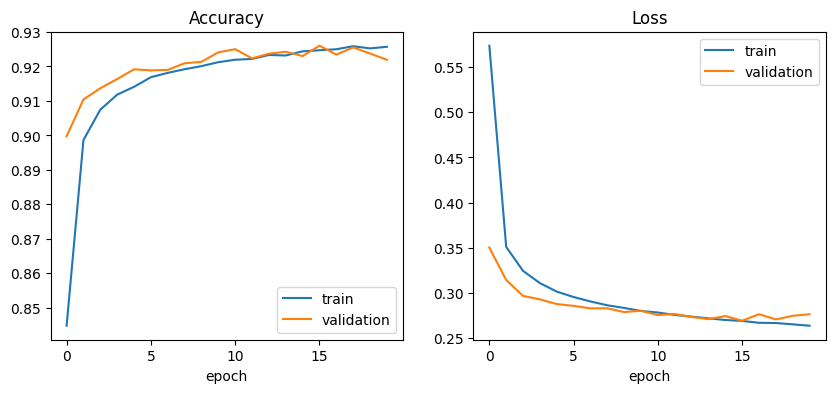

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy'); plt.xlabel('epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss'); plt.xlabel('epoch'); plt.legend()
plt.show()

### Try this

* Do the training and validation curves stay close, or do they separate?
* A growing gap between them is a sign of overfitting. At which epoch does it start?

Answers: the curves do stay close and overlap towards later epochs, but they have 2 very different starting points, the train being more steep than the validation line. train line starts < 0.85 accuracy and validation line starts at 0.9, and for loss, train line starts > 0.55 and validation line starting at 0.35 (both lines starting at epoch 0)

## Activity 2: Count the parameters

model.summary() prints a table of the layers and a Param # column: the number of weights the network has to
learn. This tells you how big your model really is. Run it for each model you build.

### Try this:

* How many parameters does the single-layer model (Step 5) have, compared with the deeper model?
* Set N_HIDDEN to 256, then 512, rebuild, and see how the parameter count grows.
* Most of the parameters sit in the first hidden layer. Why? (Hint: there are 784 inputs.)

Answers: Step 5 model has 7850 parameters, where as the deeper model 1 has 118282 and model 2 has 167818 and model 3 has 1457674. Increasing the N_HIDDEN variable greatly increases the amount of total parameters a model has. the input layer has most parameters because it contains all the features from the input.